In [123]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression,LogisticRegressionCV
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
pd.set_option('display.max_columns', 100)


In [124]:
df = pd.read_csv("HOSP_ADMIT.csv")
df.head()

,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,GB,SIM_GIPERT,DLIT_AG,ZSN_A,nr11,nr01,nr02,nr03,nr04,nr07,nr08,np01,np04,np05,np07,np08,np09,np10,endocr_01,endocr_02,endocr_03,zab_leg_01,zab_leg_02,zab_leg_03,zab_leg_04,zab_leg_06,S_AD_ORIT,D_AD_ORIT,O_L_POST,K_SH_POST,MP_TP_POST,SVT_POST,GT_POST,FIB_G_POST,ant_im,lat_im,inf_im,post_im,IM_PG_P,ritm_ecg_p_01,ritm_ecg_p_02,ritm_ecg_p_04,ritm_ecg_p_06,ritm_ecg_p_07,ritm_ecg_p_08,n_r_ecg_p_01,n_r_ecg_p_02,n_r_ecg_p_03,n_r_ecg_p_04,n_r_ecg_p_05,n_r_ecg_p_06,n_r_ecg_p_08,n_r_ecg_p_09,n_r_ecg_p_10,n_p_ecg_p_01,n_p_ecg_p_03,n_p_ecg_p_04,n_p_ecg_p_05,n_p_ecg_p_06,n_p_ecg_p_07,n_p_ecg_p_08,n_p_ecg_p_09,n_p_ecg_p_10,n_p_ecg_p_11,n_p_ecg_p_12,fibr_ter_01,fibr_ter_02,fibr_ter_03,fibr_ter_05,fibr_ter_06,fibr_ter_07,fibr_ter_08,ALT_BLOOD,AST_BLOOD,L_BLOOD,ROE,TIME_B_S,NITR_S,OUTCOME
0,77.0,1,2.0,1,1,2,3,0,7.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,180.0,100.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0.497883,0.290381,8.000000,16.000000,4.0,0,0
1,55.0,1,1.0,0,0,0,0,0,0.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,120.0,90.0,0,0,0,0,0,0,4,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.380000,0.180000,7.800000,3.000000,2.0,0,0
2,52.0,1,0.0,0,0,2,2,0,2.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,180.0,100.0,0,0,0,0,0,0,4,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.300000,0.110000,10.800000,10.480830,3.0,0,0
3,68.0,0,0.0,0,0,2,2,0,3.0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,120.0,70.0,0,0,0,0,0,0,0,1,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.750000,0.370000,8.354193,16.070233,2.0,0,0
4,60.0,1,0.0,0,0,2,3,0,7.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,160.0,90.0,0,0,0,0,0,0,4,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.450000,0.220000,8.300000,14.058981,9.0,0,0


In [125]:
df.shape
#1700 samples and 85 variables n>p big risk of overfitting

(1700, 85)

In [126]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1700 entries, 0 to 1699
Data columns (total 85 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   AGE            1700 non-null   float64
 1   SEX            1700 non-null   int64  
 2   INF_ANAM       1700 non-null   float64
 3   STENOK_AN      1700 non-null   int64  
 4   FK_STENOK      1700 non-null   int64  
 5   IBS_POST       1700 non-null   int64  
 6   GB             1700 non-null   int64  
 7   SIM_GIPERT     1700 non-null   int64  
 8   DLIT_AG        1700 non-null   float64
 9   ZSN_A          1700 non-null   int64  
 10  nr11           1700 non-null   int64  
 11  nr01           1700 non-null   int64  
 12  nr02           1700 non-null   int64  
 13  nr03           1700 non-null   int64  
 14  nr04           1700 non-null   int64  
 15  nr07           1700 non-null   int64  
 16  nr08           1700 non-null   int64  
 17  np01           1700 non-null   int64  
 18  np04           1700

In [127]:
df.dtypes

AGE          float64
SEX            int64
INF_ANAM     float64
STENOK_AN      int64
FK_STENOK      int64
              ...   
L_BLOOD      float64
ROE          float64
TIME_B_S     float64
NITR_S         int64
OUTCOME        int64
Length: 85, dtype: object

In [128]:
df.describe()

,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,GB,SIM_GIPERT,DLIT_AG,ZSN_A,nr11,nr01,nr02,nr03,nr04,nr07,nr08,np01,np04,np05,np07,np08,np09,np10,endocr_01,endocr_02,endocr_03,zab_leg_01,zab_leg_02,zab_leg_03,zab_leg_04,zab_leg_06,S_AD_ORIT,D_AD_ORIT,O_L_POST,K_SH_POST,MP_TP_POST,SVT_POST,GT_POST,FIB_G_POST,ant_im,lat_im,inf_im,post_im,IM_PG_P,ritm_ecg_p_01,ritm_ecg_p_02,ritm_ecg_p_04,ritm_ecg_p_06,ritm_ecg_p_07,ritm_ecg_p_08,n_r_ecg_p_01,n_r_ecg_p_02,n_r_ecg_p_03,n_r_ecg_p_04,n_r_ecg_p_05,n_r_ecg_p_06,n_r_ecg_p_08,n_r_ecg_p_09,n_r_ecg_p_10,n_p_ecg_p_01,n_p_ecg_p_03,n_p_ecg_p_04,n_p_ecg_p_05,n_p_ecg_p_06,n_p_ecg_p_07,n_p_ecg_p_08,n_p_ecg_p_09,n_p_ecg_p_10,n_p_ecg_p_11,n_p_ecg_p_12,fibr_ter_01,fibr_ter_02,fibr_ter_03,fibr_ter_05,fibr_ter_06,fibr_ter_07,fibr_ter_08,ALT_BLOOD,AST_BLOOD,L_BLOOD,ROE,TIME_B_S,NITR_S,OUTCOME
count,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000,1700.000000
mean,61.851103,0.626471,0.554669,2.274118,1.166471,1.160588,1.395882,0.033529,3.500965,0.188235,0.024706,0.002353,0.011176,0.020588,0.017647,0.000588,0.002353,0.001176,0.001765,0.006471,0.000588,0.003529,0.001176,0.001765,0.134118,0.024706,0.007647,0.078824,0.071176,0.021765,0.005294,0.012941,135.013760,83.126757,0.064706,0.027647,0.067647,0.004706,0.004706,0.008824,1.528824,0.832941,1.090588,0.250000,0.029412,0.691176,0.058235,0.013529,0.000588,0.208824,0.027059,0.034118,0.004706,0.120588,0.040588,0.041765,0.020000,0.002353,0.001176,0.001176,0.001176,0.018824,0.002941,0.001176,0.015882,0.060000,0.004118,0.005882,0.020000,0.016471,0.045882,0.007647,0.009412,0.040000,0.002353,0.005294,0.003529,0.001176,0.480839,0.263404,8.779090,13.516404,4.705428,0.114706,0.159412
std,11.237768,0.483883,0.835843,2.443507,1.045152,0.804329,1.087835,0.180067,2.910253,0.649065,0.155273,0.048464,0.105157,0.142043,0.131704,0.024254,0.048464,0.034290,0.041984,0.080203,0.024254,0.059321,0.034290,0.041984,0.340879,0.155273,0.087138,0.269542,0.257195,0.145957,0.072589,0.113054,29.130496,16.978907,0.246079,0.164008,0.251213,0.068458,0.068458,0.093546,1.709921,0.876935,1.448355,0.686518,0.169007,0.462144,0.234257,0.115560,0.024254,0.406588,0.162303,0.181585,0.068458,0.325744,0.197392,0.200110,0.140041,0.048464,0.034290,0.034290,0.034290,0.135941,0.054169,0.034290,0.125057,0.237557,0.064055,0.076493,0.140041,0.127314,0.209291,0.087138,0.096585,0.196017,0.048464,0.072589,0.059321,0.034290,0.355031,0.185386,3.286341,10.652132,2.774557,0.318760,0.366167
min,26.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000

In [129]:
#Test for any missing data in the columns
df.isna().mean()*100

AGE          0.0
SEX          0.0
INF_ANAM     0.0
STENOK_AN    0.0
FK_STENOK    0.0
            ... 
L_BLOOD      0.0
ROE          0.0
TIME_B_S     0.0
NITR_S       0.0
OUTCOME      0.0
Length: 85, dtype: float64

In [130]:
#See if there is any column that doesnt have a variation in the value
df.nunique()

AGE           70
SEX            2
INF_ANAM       8
STENOK_AN      7
FK_STENOK      5
            ... 
L_BLOOD      299
ROE          261
TIME_B_S     135
NITR_S         2
OUTCOME        2
Length: 85, dtype: int64

In [131]:
df.loc[df.duplicated()]
#None of the rows is duplicated

,AGE,SEX,INF_ANAM,STENOK_AN,FK_STENOK,IBS_POST,GB,SIM_GIPERT,DLIT_AG,ZSN_A,nr11,nr01,nr02,nr03,nr04,nr07,nr08,np01,np04,np05,np07,np08,np09,np10,endocr_01,endocr_02,endocr_03,zab_leg_01,zab_leg_02,zab_leg_03,zab_leg_04,zab_leg_06,S_AD_ORIT,D_AD_ORIT,O_L_POST,K_SH_POST,MP_TP_POST,SVT_POST,GT_POST,FIB_G_POST,ant_im,lat_im,inf_im,post_im,IM_PG_P,ritm_ecg_p_01,ritm_ecg_p_02,ritm_ecg_p_04,ritm_ecg_p_06,ritm_ecg_p_07,ritm_ecg_p_08,n_r_ecg_p_01,n_r_ecg_p_02,n_r_ecg_p_03,n_r_ecg_p_04,n_r_ecg_p_05,n_r_ecg_p_06,n_r_ecg_p_08,n_r_ecg_p_09,n_r_ecg_p_10,n_p_ecg_p_01,n_p_ecg_p_03,n_p_ecg_p_04,n_p_ecg_p_05,n_p_ecg_p_06,n_p_ecg_p_07,n_p_ecg_p_08,n_p_ecg_p_09,n_p_ecg_p_10,n_p_ecg_p_11,n_p_ecg_p_12,fibr_ter_01,fibr_ter_02,fibr_ter_03,fibr_ter_05,fibr_ter_06,fibr_ter_07,fibr_ter_08,ALT_BLOOD,AST_BLOOD,L_BLOOD,ROE,TIME_B_S,NITR_S,OUTCOME


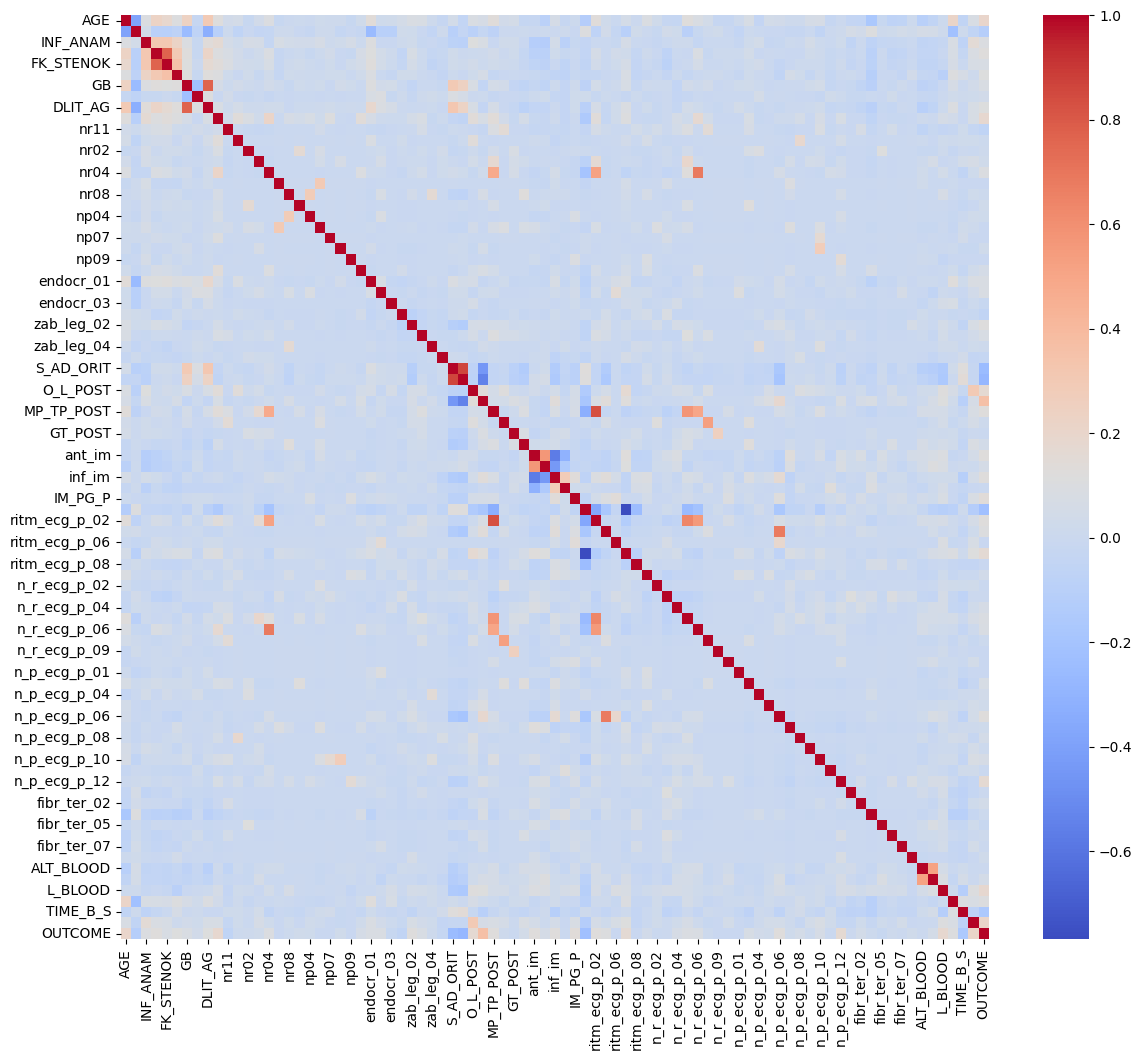

In [132]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(14,12))
sns.heatmap(corr,cmap="coolwarm")
plt.show()

## Unregularized Model

In [133]:
#Dropping the variables that have high multicollinearity
columns_to_drop = ['D_AD_ORIT', 'AST_BLOOD', 'FK_STENOK']
df_clean = df.drop(columns=columns_to_drop)

#Separate the predictores from the target
x = df_clean.drop(columns=['OUTCOME'])
y = df_clean['OUTCOME']

print(f"Remaining predictors: {x.shape[1]}")

Remaining predictors: 81


In [134]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2,random_state=42, stratify=y)
print(f"Training on {x_train.shape[0]} patients, Testing on {x_test.shape[0]} patients.")

Training on 1360 patients, Testing on 340 patients.


In [135]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test) 

In [136]:
unreg_model = LogisticRegression(penalty=None,max_iter=1000)
unreg_model.fit(x_train_scaled,y_train)


c:\Users\José Santos Costa\Statistical-Methods-Assignment-II\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",None
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [137]:
y_pred = unreg_model.predict(x_test_scaled)
y_pred_proba = unreg_model.predict_proba(x_test_scaled)[:,1]

print("--- Baseline Unregularized Model Performance ---")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.3f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

--- Baseline Unregularized Model Performance ---
ROC-AUC Score: 0.783

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.94      0.92       286
           1       0.59      0.43      0.49        54

    accuracy                           0.86       340
   macro avg       0.74      0.68      0.71       340
weighted avg       0.85      0.86      0.85       340



Our baseline unregularized model achieved an apparent accuracy of 86%, but this was largely driven by class imbalance (predicting the majority class of survival). The model struggled significantly to identify mortality, achieving a Class 1 recall of only 0.43, meaning it missed over half of the fatal outcomes. The overall ROC-AUC of 0.783 indicates the model is finding some signal, but is likely suffering from overfitting due to the unpenalized high dimensionality. This creates a clear baseline: our upcoming LASSO, Ridge, and Random Forest models must achieve a Class 1 recall higher than 0.43 and an ROC-AUC greater than 0.783 to be considered an improvement.


## Ridge Regression Model


In [147]:
ridge_cv_model = LogisticRegressionCV(
    Cs=10,
    cv=10,
    l1_ratios=(0,),
    scoring='roc_auc',
    max_iter=2000,
    random_state=42,
    use_legacy_attributes = False
)

ridge_cv_model.fit(x_train_scaled,y_train)

print(f"The best C penalty, i.e, the inverse of lambda, is {ridge_cv_model.C_:.4f}")
print(f"Best Ridge ROC-AUC: {ridge_cv_model.scores_[1].mean(axis=0).max():.3f}")


The best C penalty, i.e, the inverse of lambda, is 0.0060
Best Ridge ROC-AUC: 0.928


## Lasso Regression Model


In [149]:
lasso_cv_model = LogisticRegressionCV(
    Cs= 10,
    cv=10,
    l1_ratios=(1,),
    scoring='roc_auc',
    max_iter=20000,
    solver='saga',
    random_state=42,
    use_legacy_attributes = False
)
lasso_cv_model.fit(x_train_scaled,y_train)
print(f"Best LASSO C penalty: {lasso_cv_model.C_:.4f}")
print(f"Best LASSO ROC-AUC: {lasso_cv_model.scores_[1].mean(axis=0).max():.3f}")


Best LASSO C penalty: 0.3594
Best LASSO ROC-AUC: 0.913


c:\Users\José Santos Costa\Statistical-Methods-Assignment-II\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\José Santos Costa\Statistical-Methods-Assignment-II\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\José Santos Costa\Statistical-Methods-Assignment-II\.venv\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


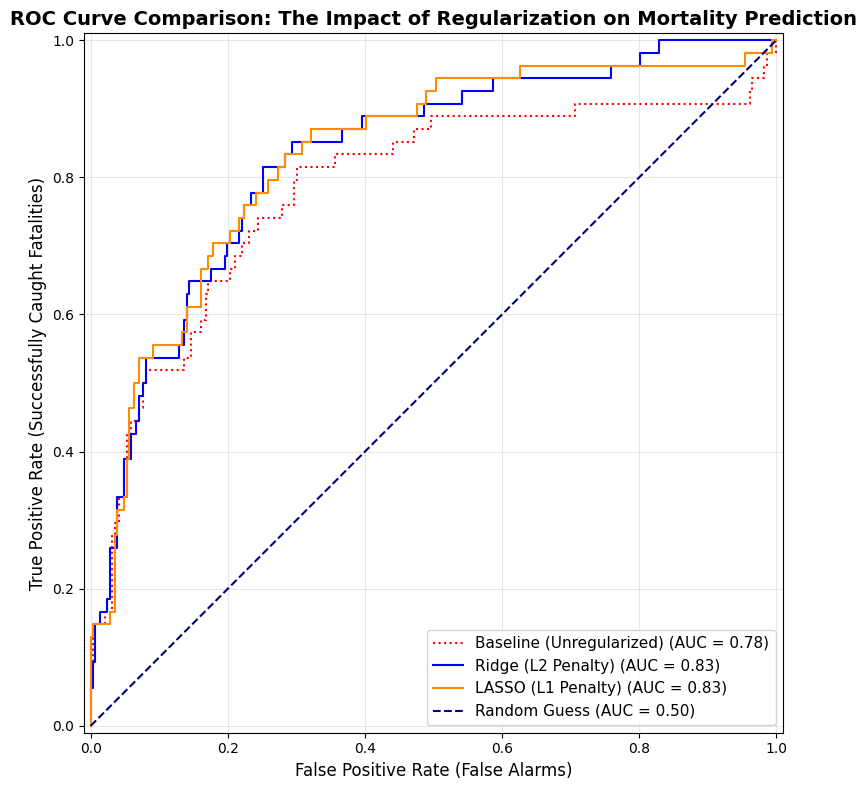

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(10, 8))
ax = plt.gca()

RocCurveDisplay.from_estimator(
    unreg_model, 
    x_test_scaled, 
    y_test, 
    name="Baseline (Unregularized)",
    color="red",         
    linestyle=':',       
    ax=ax 
)

RocCurveDisplay.from_estimator(
    ridge_cv_model, 
    x_test_scaled, 
    y_test, 
    name="Ridge (L2 Penalty)",
    color="blue",
    ax=ax 
)

RocCurveDisplay.from_estimator(
    lasso_cv_model, 
    x_test_scaled, 
    y_test, 
    name="LASSO (L1 Penalty)",
    color="darkorange",
    ax=ax 
)

plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label="Random Guess (AUC = 0.50)")

plt.title("ROC Curve Comparison: The Impact of Regularization on Mortality Prediction", fontsize=14, fontweight='bold')
plt.xlabel("False Positive Rate (False Alarms)", fontsize=12)
plt.ylabel("True Positive Rate (Successfully Caught Fatalities)", fontsize=12)
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

Both regularized models drastically outperformed the unregularized baseline (AUC 0.783). Ridge Regression achieved the highest overall discriminatory power (AUC 0.928) with a heavy penalty parameter (C=0.0060), suggesting that mortality risk in this dataset is distributed across many weak predictors rather than a few strong ones. LASSO also performed exceptionally well (AUC 0.913), offering a highly competitive alternative that benefits from automated feature selection, which may be more clinically viable for rapid patient assessment.
